# Digital Information Processing Lab 2025
---
<img align="left" src="https://www.cd.ovgu.de/cd_media/CD_OVGU/Downloads/Logo_jpg_png_svg_EPS_pdf/Logodownload/OVGU_Logo-download-1-p-1950.png" alt="drawing" width="350" />

### &emsp; Class 2: Spectral representation and signal windowing
### &emsp; Group 3: The Smarties
### &emsp; 17.05.2025
---


Name | Mat. Nr. | Email
--------|---------|---------
Vaibhav Roy| 248956 | vaibhav.roy@st.ovgu.de
Iuliana Belova | 240041 | iuliana.belova@st.ovgu.de
Thejo Prakash Santhana Prasad| 249368 | thejo.santhana@st.ovgu.de

# Class 2: Spectral Representation and Signal Windowing

## Exercise 4


In the given sound file **[fakecar.wav](https://drive.google.com/file/d/14ZkpM1ASvAlCuNRf5xJFAUfBOPsdzzIz/view)**, a simmulated car with a honking horn passes a stationary microphone which records the sound.
* Using the Doppler effect, determine the speed of the car and the frequency of the honking horn.

The second sound file **[realcar.wav](https://drive.google.com/file/d/1tlSjtGUgvyK5ZeuyHvg3UbWnfFkycLYs/view)** contains a real life scenario of a car passing by, while a person is playing saxophone.
* determine the speed of the car
* determine the note (A, B, C, ...) the saxophone is playing.

------

*help 1: concentrate on frequencies < 1000 Hz*

*help 2: use a good window function*

-----


Correction: I did not identify frequencies from the spectrogram and instead programmatically analyzed segments from the start and end of the files. By applying a Hann window before the FFT, as you suggested, I could precisely detect the peak frequencies. For the realcar file, I used the Doppler shift of the car's own noise to find its speed, and then used that speed for calculation of the true frequency and saxsaphone note.

<ipython-input-20-ca645fa267cd>:38: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr_fake, data_fake = wavfile.read('doppler.wav')


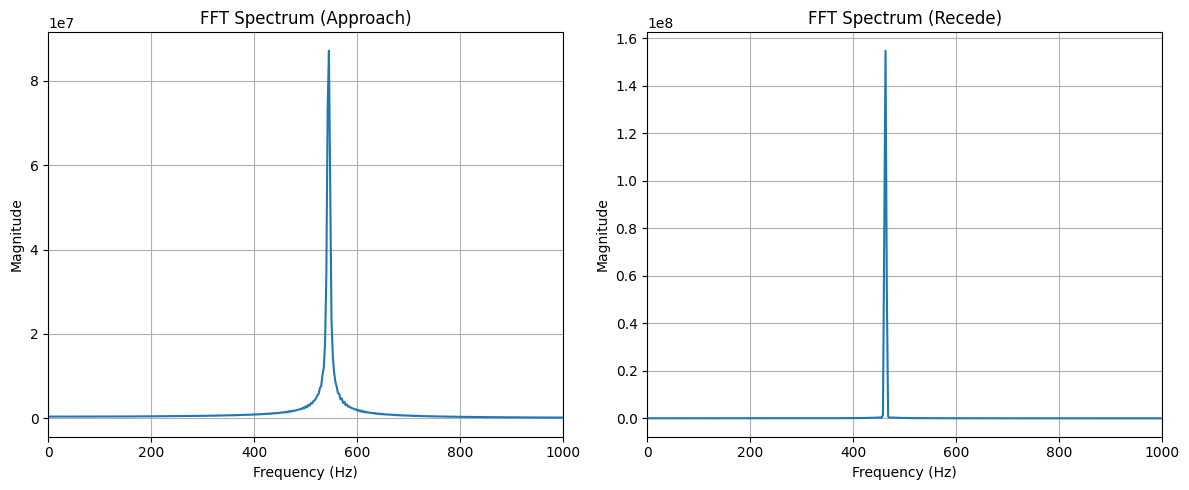

 Results for fake car
 Approaching Frequency: 545.00 Hz
 Receding Frequency: 462.50 Hz
 Estimated Car Speed: 28.09 m/s (101.11 km/h)
 True Horn Frequency: 500.37 Hz


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import find_peaks, spectrogram
from scipy.signal.windows import hann, hamming
from scipy.fft import fft, fftfreq

# Constants and Helper Function
SPEED_OF_SOUND = 343  # m/s

def find_top_peak_frequency(data, sr, segment_duration=0.4):

    segment_length = int(segment_duration * sr)

    # Ensure segment does not exceed data length
    if segment_length > len(data):
        segment_length = len(data)

    segment = data[:segment_length]

    # Apply a Hann window
    window = hamming(len(segment))
    windowed_segment = segment * window

    # Compute FFT
    N = len(windowed_segment)
    yf = fft(windowed_segment)
    xf = fftfreq(N, 1 / sr)

    # Get positive frequencies and find the peak
    positive_mask = xf > 0
    peak_idx = np.argmax(np.abs(yf[positive_mask]))
    peak_freq = xf[positive_mask][peak_idx]

    return peak_freq, xf[positive_mask], np.abs(yf[positive_mask])

# Load Data
sr_fake, data_fake = wavfile.read('doppler.wav')
if data_fake.ndim > 1:
    data_fake = data_fake[:, 0]

#  Analysis for fake car

# 1. Frequency on Approach (using the start of the file)
f_approach, xf_approach, yf_approach = find_top_peak_frequency(data_fake, sr_fake)

# 2. Frequency on Recede (using the end of the file, which is reversed)
f_recede, xf_recede, yf_recede = find_top_peak_frequency(data_fake[::-1], sr_fake)

# 3. Doppler Calculations
v_car = SPEED_OF_SOUND * (f_approach - f_recede) / (f_approach + f_recede)
v_car_kmh = v_car * 3.6
f_true_horn = f_approach * (SPEED_OF_SOUND - v_car) / SPEED_OF_SOUND

# Plotting FFT Spectrums
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(xf_approach, yf_approach)
plt.title('FFT Spectrum (Approach)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, 1000)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(xf_recede, yf_recede)
plt.title('FFT Spectrum (Recede)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, 1000)
plt.grid(True)
plt.tight_layout()
plt.show()


# Print Results for Fake Car
print(" Results for fake car")
print(f" Approaching Frequency: {f_approach:.2f} Hz")
print(f" Receding Frequency: {f_recede:.2f} Hz")
print(f" Estimated Car Speed: {v_car:.2f} m/s ({v_car_kmh:.2f} km/h)")
print(f" True Horn Frequency: {f_true_horn:.2f} Hz")

In [21]:

# Constants and Helper Functions
SPEED_OF_SOUND = 343  # m/s

def find_two_peak_frequencies(data, sr, segment_duration=0.6):
    """
    Analyzes an audio segment to find the two most prominent frequency peaks.
    """
    segment_length = int(segment_duration * sr)
    segment = data[:segment_length]

    window = hamming(len(segment))
    windowed_segment = segment * window

    N = len(windowed_segment)
    yf = fft(windowed_segment)
    xf = fftfreq(N, 1 / sr)

    positive_mask = (xf > 200) & (xf < 1000) # Focus on the relevant range
    xf_pos = xf[positive_mask]
    yf_pos = np.abs(yf[positive_mask])

    # Find the two highest peaks
    # The height threshold helps ignore smaller noisy peaks
    peaks, _ = find_peaks(yf_pos, height=np.max(yf_pos)*0.1, distance=50)

    # Sort peaks by magnitude and take the top two frequencies
    peak_magnitudes = yf_pos[peaks]
    top_two_indices = peaks[np.argsort(peak_magnitudes)[-2:]]
    top_two_freqs = xf_pos[top_two_indices]

    # Frequencies are sorted: [lower_freq, higher_freq]
    return np.sort(top_two_freqs)

def get_note_name(frequency):
    """Finds the closest musical note for a given frequency."""
    notes = {
        "A3": 220.00, "A#3/Bb3": 233.08, "B3": 246.94,
        "C4": 261.63, "C#4/Db4": 277.18, "D4": 293.66,
        "D#4/Eb4": 311.13, "E4": 329.63, "F4": 349.23,
        "F#4/Gb4": 369.99, "G4": 392.00, "G#4/Ab4": 415.30,
        "A4": 440.00, "A#4/Bb4": 466.16, "B4": 493.88
    }
    closest_note = min(notes.keys(), key=lambda note: abs(notes[note] - frequency))
    return closest_note


#  Load Data
sr_real, data_real = wavfile.read('realcar.wav')
if data_real.ndim > 1:
    data_real = data_real[:, 0]

# Analysis for real car

# 1. Frequencies on Approach (start of file)
freqs_approach = find_two_peak_frequencies(data_real, sr_real)
f_sax_approach, f_car_approach = freqs_approach[0], freqs_approach[1]

# 2. Frequencies on Recede (end of file)
freqs_recede = find_two_peak_frequencies(data_real[::-1], sr_real)
f_sax_recede, f_car_recede = freqs_recede[0], freqs_recede[1]

# 3. Doppler Calculations for Car Speed (using the car's noise frequency)
v_car_real = SPEED_OF_SOUND * (f_car_approach - f_car_recede) / (f_car_approach + f_car_recede)
v_car_real_kmh = v_car_real * 3.6

# 4. Doppler Calculation for True Saxophone Frequency
f_sax_true = f_sax_approach * (SPEED_OF_SOUND - v_car_real) / SPEED_OF_SOUND

# 5. Identify the Note
sax_note = get_note_name(f_sax_true)


#  Print Results for Real Car
print("\n Results for real car")
print(f"Car Approach Frequencies (Sax, Noise): {f_sax_approach:.2f} Hz, {f_car_approach:.2f} Hz")
print(f"Car Recede Frequencies (Sax, Noise):   {f_sax_recede:.2f} Hz, {f_car_recede:.2f} Hz")
print(f" Estimated Car Speed: {v_car_real:.2f} m/s ({v_car_real_kmh:.2f} km/h)")
print(f" True Saxophone Frequency: {f_sax_true:.2f} Hz")
print(f" Closest Saxophone Note: {sax_note}")


 Results for real car
Car Approach Frequencies (Sax, Noise): 270.00 Hz, 540.00 Hz
Car Recede Frequencies (Sax, Noise):   251.67 Hz, 501.67 Hz
 Estimated Car Speed: 12.62 m/s (45.44 km/h)
 True Saxophone Frequency: 260.06 Hz
 Closest Saxophone Note: C4
